Calcul de la matrice de recouvrement S...

Matrice de recouvrement S (complexe) :
[[3.6043e+00-1.9905e+01j 1.0201e+02-3.0134e+02j 1.5017e+03-3.0632e+03j
  1.5876e+04-2.5139e+04j 1.3263e+05-1.7424e+05j]
 [1.0456e+02-3.1542e+02j 2.1994e+03-4.5650e+03j 2.8704e+04-4.6135e+04j
  2.7908e+05-3.7157e+05j 2.2642e+06-2.6703e+06j]
 [1.6050e+03-3.3716e+03j 2.9805e+04-4.8427e+04j 3.5729e+05-4.8054e+05j
  3.3655e+06-4.0009e+06j 2.7011e+07-2.8292e+07j]
 [1.7778e+04-2.9078e+04j 3.0303e+05-4.1035e+05j 3.5123e+06-4.1990e+06j
  3.2693e+07-3.4480e+07j 2.5757e+08-2.5203e+08j]
 [1.5641e+05-2.1254e+05j 2.5738e+06-3.0868e+06j 2.9459e+07-3.1219e+07j
  2.6926e+08-2.6439e+08j 2.1339e+09-1.9086e+09j]]


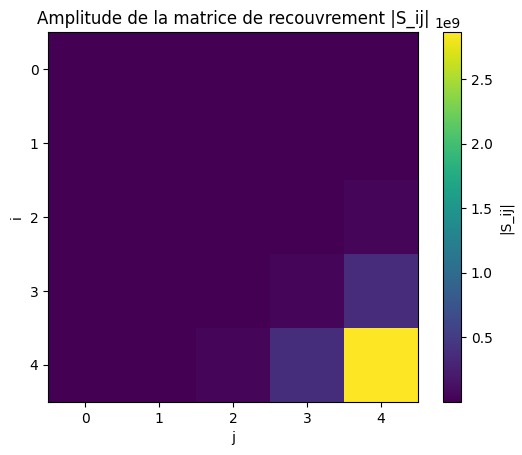

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.special import hermite, gamma
from numpy import sqrt, exp, pi

# --------------------------
# Paramètres des deux bases
# --------------------------
alpha1 = 1.0 + 0.5j
q1 = 0.0
p1 = 0.0

alpha2 = 1.0 - 0.5j
q2 = 0.5
p2 = 0.0

# Nombre de fonctions de base
N = 5

# --------------------------
# Fonction de base d'Hagedorn
# --------------------------
def hagedorn(n, q, alpha, q0, p0):
    xi = sqrt(alpha.real) * (q - q0)
    Hn = hermite(n)(xi)
    norm = (alpha.real / pi)**0.25 / sqrt(2**n * float(gamma(n + 1)))
    phase = exp(-1j / 2 * alpha * (q - q0)**2 + 1j * p0 * (q - q0))
    return norm * Hn * phase

# --------------------------
# Fonction de recouvrement S_ij = <b_i | b_j>
# --------------------------
def overlap(i, j):
    def integrand(q):
        b_i = np.conj(hagedorn(i, q, alpha1, q1, p1))
        b_j = hagedorn(j, q, alpha2, q2, p2)
        return b_i * b_j

    # Centrer la fenêtre sur le milieu des centres
    qmid = (q1 + q2) / 2
    L = 12 / sqrt(min(alpha1.real, alpha2.real))  # largeur raisonnable

    real, _ = quad(lambda q: integrand(q).real, qmid - L, qmid + L, limit=200)
    imag, _ = quad(lambda q: integrand(q).imag, qmid - L, qmid + L, limit=200)
    return real + 1j * imag

# --------------------------
# Construction de la matrice
# --------------------------
S = np.zeros((N, N), dtype=complex)

print("Calcul de la matrice de recouvrement S...")
for i in range(N):
    for j in range(N):
        S[i, j] = overlap(i, j)

# --------------------------
# Affichage
# --------------------------
np.set_printoptions(precision=4, suppress=True)
print("\nMatrice de recouvrement S (complexe) :")
print(S)

# (optionnel) visualisation
plt.imshow(np.abs(S), cmap='viridis')
plt.colorbar(label='|S_ij|')
plt.title('Amplitude de la matrice de recouvrement |S_ij|')
plt.xlabel('j')
plt.ylabel('i')
plt.show()